# Airline Fare Prediction

<center>
    <img src="airplane_banner.png" width="100%" style="max-height: 450px; object-fit: cover;">
<center/>

### What we often do in this use-case
    High level over-view..
    
   
    Note :->>
    
    We will solve most of those challenges that we often face in real world..
    we will focus primarily on each & every part of data science life-cycle..
    
    
     Life- Cycle of Data Science Project :
        a) Data collection
        b) Perform Data Cleaning / Data Preparation / Data Pre-processing 
        c) Data visuaslisation(EDA)
        d) Perform feature engineering
            I)  Feature encoding
            II) checking outliers & impute it..
            III)Feature selection or feature importance
            
        e) build machine leaning model & dump it..
        f) Automate ML Pipeline 
        g) hypertune ml model..along with cross validation

    

## 1..Import the basic libraries

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

## Reading the Dataset
    Since DataSet is in the form of Excel so for loading the dataset we have to use pandas read_excel...

In [201]:
# !pip install openpyxl

In [202]:
data_train = pd.read_excel("Data_Train.xlsx")

#### Display the loaded Dataset
    so to display the loaded dataset we will use head() for quickly view few rows of the dataset,when we load dataset it might contain thousands and  even millions of rows to avoid displaying the entire dataset we use head() to view first few rows... 

In [203]:
data_train.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [204]:
data_train.tail(10)# to quickyly view last few rows of the loaded dataset

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10673,Jet Airways,27/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,13:25,04:25 28 May,15h,2 stops,No info,16704
10674,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,20:35,21:20 13 Mar,24h 45m,1 stop,In-flight meal not included,11087
10675,Air India,9/06/2019,Mumbai,Hyderabad,BOM → HYD,06:20,07:40,1h 20m,non-stop,No info,3100
10676,Multiple carriers,1/05/2019,Delhi,Cochin,DEL → BOM → COK,10:20,19:00,8h 40m,1 stop,No info,9794
10677,SpiceJet,21/05/2019,Banglore,Delhi,BLR → DEL,05:55,08:35,2h 40m,non-stop,No check-in baggage included,3257
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


## 3..Lets Start with Data cleaning and Data preprocessing
    Lets start dealing with missing values first...

In [205]:
data_train.info() # first we will start will .info() method  and this tell us about structure and completeness of data like and also view like --there  may be some missing value in any of the columns of the dataset 

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB


In [206]:
'''

10 features belong to object data-type , ie.. in context to Python , they belong to string data-type

            
1 feature belong to int64 nature  , ie 
Variations of int are : ('int64','int32','int16') in numpy library..



Int16 is a 16 bit signed integer , it means it can store both positive & negative values
int16 has has a range of  (2^15 − 1) to -2^15 
int16 has a length of 16 bits (2 bytes).. ie Int16 uses 16 bits to store data


Int32 is a 32 bit signed integer , it means it storesboth positive & negative values
int32 has has a range of (2³¹ − 1) to  -2^31
int32 has a length of 32 bits (4 bytes),, ie Int32 uses 32 bits to store data


Int64 is a 64 bit signed integer , it means it can store both positive & negative values
int64 has has a range of  (2^63 − 1) to -2^63 
int64 has a length of 64 bits (8 bytes) , ie Int64 uses 64 bits to store data
            
The only difference is that int64 has max range of storing numbers , then comes int32 , then 16 , then int8

That means that Int64’s take up twice as much memory-and doing 
operations on them may be a lot slower in some machine architectures.

However, Int64’s can represent numbers much more accurately than 
32 bit floats.They also allow much larger numbers to be stored..







The memory usage of a DataFrame (including the index) is shown when calling the info(). 
A configuration option, display.memory_usage (see the list of options), specifies if the DataFrame’s memory usage 
 will be displayed when invoking the df.info() method..
 
memory usage: 918.2+ KB 
The + symbol indicates that the true memory usage could be higher, 
because pandas does not count the memory used by values in columns with dtype=object


Passing memory_usage='deep' will enable a more accurate memory usage report .

'''

"\n\n10 features belong to object data-type , ie.. in context to Python , they belong to string data-type\n\n\n1 feature belong to int64 nature  , ie \nVariations of int are : ('int64','int32','int16') in numpy library..\n\n\n\nInt16 is a 16 bit signed integer , it means it can store both positive & negative values\nint16 has has a range of  (2^15 − 1) to -2^15 \nint16 has a length of 16 bits (2 bytes).. ie Int16 uses 16 bits to store data\n\n\nInt32 is a 32 bit signed integer , it means it storesboth positive & negative values\nint32 has has a range of (2³¹ − 1) to  -2^31\nint32 has a length of 32 bits (4 bytes),, ie Int32 uses 32 bits to store data\n\n\nInt64 is a 64 bit signed integer , it means it can store both positive & negative values\nint64 has has a range of  (2^63 − 1) to -2^63 \nint64 has a length of 64 bits (8 bytes) , ie Int64 uses 64 bits to store data\n\nThe only difference is that int64 has max range of storing numbers , then comes int32 , then 16 , then int8\n\nThat m

#### so it's now important to check for any null/missing values in row or column
    Missing values: missing values are entries in the dataset where no information is recorded for particular observations or features...

In [207]:
data_train.isnull()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
10678,False,False,False,False,False,False,False,False,False,False,False
10679,False,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,False,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,False,False


In [208]:
data_train.isnull().sum()
# data_train.isnull().sum(axis = 0) 
# so here in [sum(axis = 0)by default here axis = 0 i.e it compute total missing value column wise... ]

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [209]:
data_train['Total_Stops'].isnull().sum() # here i get i row where we can see the missing value

np.int64(1)

In [210]:
data_train[data_train['Total_Stops'].isnull()] # getting all rows where we  have missing value

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


#### As i can see only one missing value...
    so i can simply drop these

In [211]:
data_train.dropna(inplace=True) # dropna() -- remove missing value rows/columns

In [212]:
data_train.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [213]:
data_train.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

**In order to gain deeper insights into memory usage ,we can levarage deep = True parameter in info() method --( memory_usage = 'deep')**

In [214]:
data_train.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Date_of_Journey  10682 non-null  str  
 2   Source           10682 non-null  str  
 3   Destination      10682 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10682 non-null  str  
 6   Arrival_Time     10682 non-null  str  
 7   Duration         10682 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10682 non-null  str  
 10  Price            10682 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.9 MB


## 3.. Lets perform Data Preprocessing & extract derived attributes from "Date_of_Journey"
     Derived attributes: are new attributes created from exiting information through calculation..
     1.Lets extract derived attributes from "Date_of_Journey" & fetch Day, month & year!

In [215]:
df = data_train.copy() #we use copy method to create a separate dataframe or series ,so that changes made to the copy do not effect the original data,so create a copy for cleaning and preprocessing you can work safely without changing original datase

In [216]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [217]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [218]:
df.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

# So from above description we can see that "Date_of_Journey" is in the form of string(str) datatype..
    Therefore,we need to convert the string datatype into proper datetime formate,so that we can use this column effectively for prediction,ml models can't directly process raw string values as numerical features, for this conversion we can use Pandas' to_datetime() method, which converts string values to a datetime format...
    

In [219]:
'''
In date-time , we have 4 data-types in Pandas :
datetime64[ns] or datetime64[ns, tz]  or datetime64[ns, UTC] or dtype('<M8[ns]')
     means ‘big-endian’  , < is little-endian
     imagine , data represented a single unsigned 4-byte little-endian integer, the dtype string would be <u4..
     (u is type-character code for unsigned integer)
     
where ,   UTC = Coordinated Universal Time
          ns  = nano second
          tz  = time zone
          M =  M is a character of Data-time , just like int we have i for "Integer" ,


datetime64[ns] is a general dtype, while <M8[ns] is a specific dtype , ns is basicaly nano second..
Both are similar , it entirely how your numpy was compiled..

np.dtype('datetime64[ns]') == np.dtype('<M8[ns]')
## True

'''

'\nIn date-time , we have 4 data-types in Pandas :\ndatetime64[ns] or datetime64[ns, tz]  or datetime64[ns, UTC] or dtype(\'<M8[ns]\')\n     means ‘big-endian’  , < is little-endian\n     imagine , data represented a single unsigned 4-byte little-endian integer, the dtype string would be <u4..\n     (u is type-character code for unsigned integer)\n\nwhere ,   UTC = Coordinated Universal Time\n          ns  = nano second\n          tz  = time zone\n          M =  M is a character of Data-time , just like int we have i for "Integer" ,\n\n\ndatetime64[ns] is a general dtype, while <M8[ns] is a specific dtype , ns is basicaly nano second..\nBoth are similar , it entirely how your numpy was compiled..\n\nnp.dtype(\'datetime64[ns]\') == np.dtype(\'<M8[ns]\')\n## True\n\n'

In [220]:
def string_to_datetime(col):
    df[col] = pd.to_datetime(df[col])

In [221]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [222]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [223]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [224]:
for feature in ['Dep_Time','Arrival_Time','Date_of_Journey']:
    string_to_datetime(feature)

In [225]:
df.dtypes

Airline                       str
Date_of_Journey    datetime64[us]
Source                        str
Destination                   str
Route                         str
Dep_Time           datetime64[us]
Arrival_Time       datetime64[us]
Duration                      str
Total_Stops                   str
Additional_Info               str
Price                       int64
dtype: object

In [226]:
df['Date_of_Journey'].dtypes # column contate M8 -datetime data time with  nanosecond precision

dtype('<M8[us]')

In [227]:
df['Date_of_Journey'].head()

0   2019-03-24
1   2019-05-01
2   2019-06-09
3   2019-05-12
4   2019-03-01
Name: Date_of_Journey, dtype: datetime64[us]

In [228]:
df['Journey_DAY'] = df['Date_of_Journey'].dt.day

In [229]:
df['Journey_MONTH'] = df['Date_of_Journey'].dt.month

In [230]:
df['Journey_YEAR'] = df['Date_of_Journey'].dt.year

In [231]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-09-21 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-09-21 05:50:00,2026-09-21 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019


## 4.. Lets try to clean Dep_Time & Arrival_Time & then extract Derived attributes ..

In [232]:
def extract_hrs_min(df1,col):
    df1[col + "_hrs"] = df1[col].dt.hour
    df1[col + "_mins"] = df1[col].dt.minute
    return df1.head(5)

In [233]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-09-21 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-09-21 05:50:00,2026-09-21 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-09-21 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-09-21 18:05:00,2026-09-21 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-09-21 16:50:00,2026-09-21 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019


In [234]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_DAY', 'Journey_MONTH',
       'Journey_YEAR'],
      dtype='str')

In [235]:
extract_hrs_min(df,'Dep_Time')#departure time means when the plain leave the airport...

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR,Dep_Time_hrs,Dep_Time_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-09-21 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-09-21 05:50:00,2026-09-21 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-09-21 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-09-21 18:05:00,2026-09-21 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-09-21 16:50:00,2026-09-21 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [236]:
extract_hrs_min(df,'Arrival_Time')#arrival time is time when the flight reaches the destination airport

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-09-21 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-09-21 05:50:00,2026-09-21 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-09-21 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-09-21 18:05:00,2026-09-21 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-09-21 16:50:00,2026-09-21 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


**Now we've extract the derived attributes from the columns -"Arrival_Time" & "Dep_Time" and now simply we will drop these columns there is no need of these 2 columns**

In [237]:
col_drop = ['Dep_Time','Arrival_Time']

In [238]:
df.drop(col_drop,axis=1,inplace=True) # (axis = 1) here 1 represent the columns, and (drop) is use to remove the specific colums/row which we particulary wants to remove..,(inplace = true) means change directly to the existing dataframe...

In [239]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [240]:
df.shape

(10682, 16)

# 5..Lets analyse when  most of the flights will take-off..

In [241]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_DAY',
       'Journey_MONTH', 'Journey_YEAR', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins'],
      dtype='str')

**converting flight dep_time into appropriate time i.e "early morning","noon","evening","night","latenight**

In [242]:
def flight_dep_time(x):
    '''
    This function takes the dep_time and convert
    into approriate time likewise

    '''
    if (x>4) and (x<=8):
        return "Early Morning"
    elif (x>8) and (x<=12):
        return "Morning"
    elif (x>12) and (x<=16):
        return "Noon"
    elif (x>16) and (x<=20):
        return "Evening"
    elif(x>20) and (x<=24):
        return "Night"
    else:
        return "Late Night"

<Axes: xlabel='Dep_Time_hrs'>

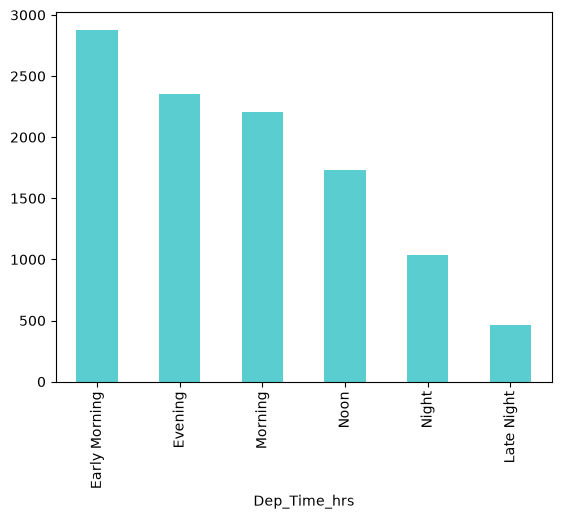

In [243]:
df['Dep_Time_hrs'].apply(flight_dep_time).value_counts().plot(kind = 'bar',color = "#5acdd1")

**Lets make this graph more interective ,for this we will use cufflinks and plotly to make interective graphs..**

In [244]:
# !pip install plotly
# !pip install chart_studio

In [245]:
# !pip install cufflinks

In [246]:

import plotly.express as px
import cufflinks as cf
from cufflinks.offline import go_offline
from plotly.offline import plot , iplot , init_notebook_mode , download_plotlyjs
init_notebook_mode(connected=True)
cf.go_offline()

#plot is command of matplotlib and make static plot
#iplot is an interactive plot,plotly takes python code to make more interactive  like javascript plots

In [247]:
counts = df['Dep_Time_hrs'].apply(flight_dep_time).value_counts()

fig = px.bar(
    x=counts.index,
    y=counts.values,
    labels={'x': 'Departure Time', 'y': 'Number of Flights'},
    title='Flight Distribution by Departure Time'
)
fig.show()

## Pre-processing Duration-features and extract meaningfull duration from it..

### Letes apply pre-processing on duration column..
    1.onces we preprocessed out duration feature,lets extract duration hrs and mins from duration columns..
    2.for the model evolution and prediction our model is not able to understand string datattypes as duration column is string based column,to make ml model to understand that this is hour and this is minute for each of the rows

In [248]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [249]:
df['Duration'].head(3)

0    2h 50m
1    7h 25m
2       19h
Name: Duration, dtype: str

In [250]:
df['Duration'].dtype

<StringDtype(na_value=nan)>

In [251]:
df['Duration'].isnull().sum()

np.int64(0)

In [252]:
def feature_duration(x):
    if 'h' not in x:
        x = '0h' + ' ' + x
    elif 'm' not in x:
        x = x + ' ' + '0m'
        
    return x

In [253]:
df['Duration'] = df['Duration'].apply(feature_duration)

In [254]:
df['Duration'].head(10)

0     2h 50m
1     7h 25m
2     19h 0m
3     5h 25m
4     4h 45m
5     2h 25m
6    15h 30m
7     21h 5m
8    25h 30m
9     7h 50m
Name: Duration, dtype: str

In [255]:
df['Duration'].tail(3)

10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, dtype: str

In [256]:
df['Duration']

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: str

In [257]:
'''  
After pre-processing with duration feature our ml model still not able to understand because duration  because column is still  in 
string datatype...
so we have to convert this string datatype into numeric(int to float)to make our model get that..
      
'''

'  \nAfter pre-processing with duration feature our ml model still not able to understand because duration  because column is still  in \nstring datatype...\nso we have to convert this string datatype into numeric(int to float)to make our model get that..\n\n'

In [258]:
df['Duration']

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: str

In [259]:
df['Duration'][0]

'2h 50m'

In [260]:
'2h 50m'.split(' ')#split method is use to divide the string into smaller part 

['2h', '50m']

In [261]:
'2h 50m'.split(' ')[0] # so here 2h is index 0,and 50m is index 1

'2h'

In [262]:
#we will divide in small part while using slicing method to get 2 instead of 2h
'2h 50m'.split(' ')[0][0:-1]

'2'

In [263]:
#so lets check the type of this above output--
type('2h 50m'.split(' ')[0][0:-1])

str

In [264]:
# after getting output of str we will simply convert this str into int while using int method
int('2h 50m'.split(' ')[0][0:-1])

2

In [265]:
'2h 50m'.split(' ')[1]

'50m'

In [266]:
'2h 50m'.split(' ')[1][0:-1]

'50'

In [267]:
int('2h 50m'.split(' ')[1][0:-1])

50

In [268]:
#now will extract derived atribte from existing attributes and extract hrs and mins column from duration_time_hr and duration_time_min
df['Duration_hrs'] = df['Duration'].apply(lambda x:int(x.split(' ')[0][0:-1]))

In [269]:
df['Duration_mins'] = df['Duration'].apply(lambda x:int(x.split(' ')[1][0:-1]))

In [270]:
df.head(4)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30,5,25


####  Now after all the pre processing processes will use timedelta method --->>
      <--timedelta method represent the difference between two dates and times-->
      <--[dt.components.hrs] and [dt.components.mins] is use to extract the hrs and mins-->


In [271]:
pd.to_timedelta(df['Duration']).dt.components.hours

0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: hours, Length: 10682, dtype: int64

In [272]:
df['Duration_hrs']  = pd.to_timedelta(df['Duration']).dt.components.hours

In [273]:
df['Duration_mins'] = pd.to_timedelta(df['Duration']).dt.components.minutes

In [274]:
df['Duration_hrs']

0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: Duration_hrs, Length: 10682, dtype: int64

In [275]:
df['Duration_mins']

0        50
1        25
2         0
3        25
4        45
         ..
10678    30
10679    35
10680     0
10681    40
10682    20
Name: Duration_mins, Length: 10682, dtype: int64

## 7.. Lets Analyse whether Duration impact Price or not?

In [276]:
df['Duration'] #convert duration  into  total minutes duration

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: str

In [277]:
12*3


36

In [278]:
'12*3'

'12*3'

In [279]:
eval('12*3')#eval in python is use to evaluate a str as a python expression

36

In [280]:
df['Duration_total_mins'] = df['Duration'].str.replace('h','*60').str.replace(' ','+').str.replace('m','*1').apply(eval)

In [281]:
df['Duration_total_mins']

0         170
1         445
2        1140
3         325
4         285
         ... 
10678     150
10679     155
10680     180
10681     160
10682     500
Name: Duration_total_mins, Length: 10682, dtype: int64

In [282]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_DAY',
       'Journey_MONTH', 'Journey_YEAR', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins', 'Duration_hrs',
       'Duration_mins', 'Duration_total_mins'],
      dtype='str')

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

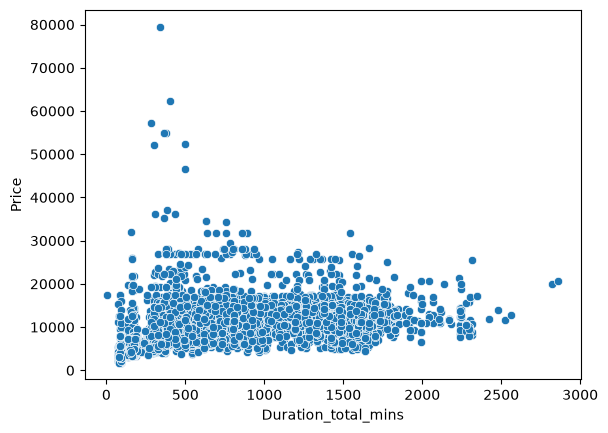

In [283]:
sns.scatterplot(x = 'Duration_total_mins',y = 'Price',data =df)

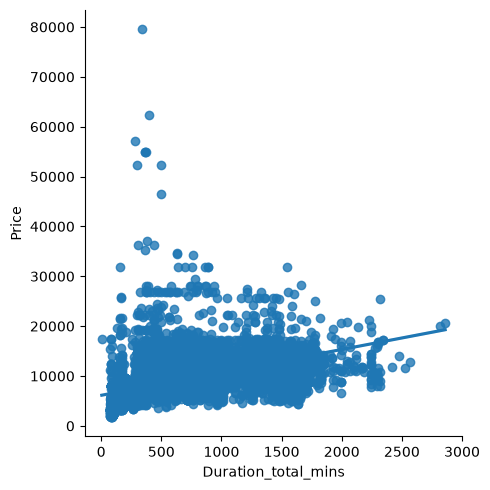

In [284]:
sns.lmplot(x ='Duration_total_mins',y = 'Price',data = df)
# clearly it shows that as  duration of minutes increases then flight prices also increases

***Lets Analyse whether total  stops affect price or not!***

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

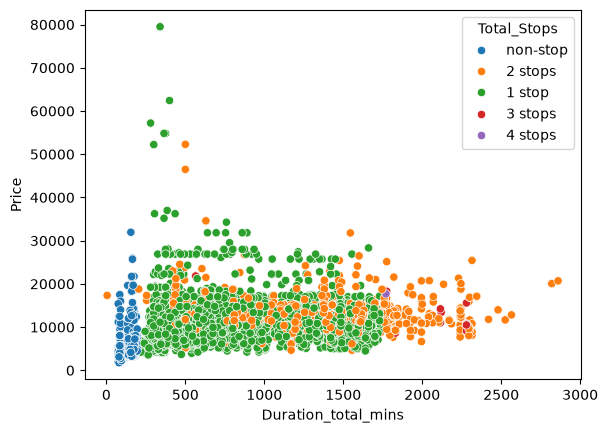

In [285]:
sns.scatterplot(x ='Duration_total_mins',y = 'Price',hue='Total_Stops',data = df)

In [286]:
'''
    Non stops flights takes less duration while their fare is also low,
    as stops increases their duration increases and their fare also increases in many of the cases
    
'''

'\n    Non stops flights takes less duration while their fare is also low,\n    as stops increases their duration increases and their fare also increases in many of the cases\n\n'

# 8.. On which route jet airways is extremly used!

In [287]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_DAY',
       'Journey_MONTH', 'Journey_YEAR', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins', 'Duration_hrs',
       'Duration_mins', 'Duration_total_mins'],
      dtype='str')

In [288]:
df['Airline'].value_counts()#here we get to know which airline is extremly in use and that is Jet Airlines 

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [289]:
df['Airline'] == 'Jet Airways'

0        False
1        False
2         True
3        False
4        False
         ...  
10678    False
10679    False
10680     True
10681    False
10682    False
Name: Airline, Length: 10682, dtype: bool

In [290]:
df[df['Airline'] == 'Jet Airways'].groupby('Route').size().sort_values(ascending=False)

Route
CCU → BOM → BLR          930
DEL → BOM → COK          875
BLR → BOM → DEL          385
BLR → DEL                382
CCU → DEL → BLR          300
DEL → JAI → BOM → COK    207
BOM → HYD                207
DEL → AMD → BOM → COK    141
DEL → IDR → BOM → COK     86
DEL → NAG → BOM → COK     61
DEL → ATQ → BOM → COK     38
DEL → COK                 34
DEL → BHO → BOM → COK     29
DEL → BDQ → BOM → COK     28
DEL → LKO → BOM → COK     25
DEL → JDH → BOM → COK     23
CCU → GAU → BLR           22
DEL → MAA → BOM → COK     16
DEL → IXC → BOM → COK     13
BLR → MAA → DEL           10
BLR → BDQ → DEL            8
DEL → UDR → BOM → COK      7
BOM → DEL → HYD            5
CCU → BOM → PNQ → BLR      4
BLR → BOM → JDH → DEL      3
DEL → DED → BOM → COK      2
BOM → BDQ → DEL → HYD      2
BOM → IDR → DEL → HYD      1
BOM → VNS → DEL → HYD      1
BOM → DED → DEL → HYD      1
BOM → JDH → DEL → HYD      1
BOM → UDR → DEL → HYD      1
DEL → CCU → BOM → COK      1
dtype: int64

### b..Performing Airlines Vs Price Analysis
     i.e find price distribution and 5-line summary of each airlines

In [291]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_DAY',
       'Journey_MONTH', 'Journey_YEAR', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins', 'Duration_hrs',
       'Duration_mins', 'Duration_total_mins'],
      dtype='str')

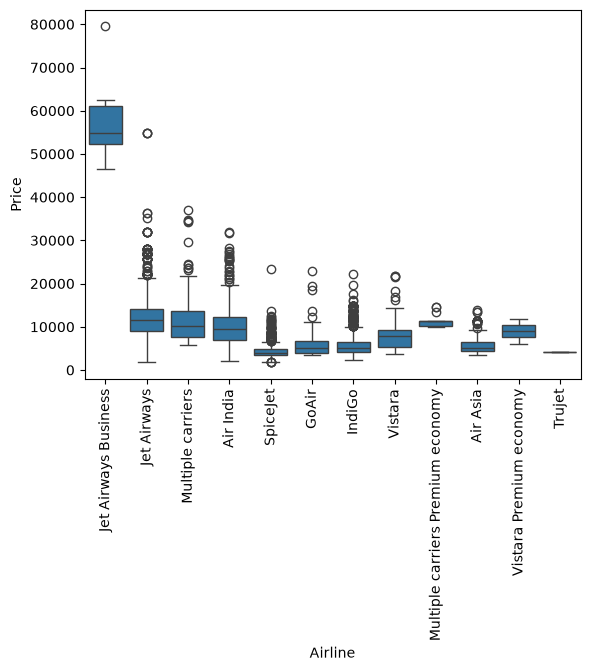

In [292]:
sns.boxplot(x = 'Airline',y = 'Price',data = df.sort_values('Price',ascending=False))
plt.xticks(rotation = 'vertical')
plt.show()

In [293]:
''' From the baove graph we can say that jet airways bussiness has the highest price..,
    apart from jet airways bussiness all have the same median..
'''

' From the baove graph we can say that jet airways bussiness has the highest price..,\n    apart from jet airways bussiness all have the same median..\n'

# 9.. Applying One-hot Encoding on data..

In [294]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,Journey_MONTH,Journey_YEAR,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25,445
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,2019,9,25,4,25,19,0,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30,5,25,325
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35,4,45,285


In [295]:
'''

Categorical data refers to a data type that can be stored into groups/categories/labels 
Examples of categorical variables are  age group, educational level,blood type etc.. 


Numerical data refers to the data that is in the form of numbers, 
Examples of numerical data are height, weight, age etc.. 

Numerical data has two categories: discrete data and continuous data


Discrete data : It basically takes countable numbers like 1, 2, 3, 4, 5, and so on. 
                In case of infinity, these numbers will keep going on...
                age of a fly : 8 , 9 day etc..
                
Continuous data : which is continuous in nature 
                  amount of sugar , 11.2 kg  , temp of a city  , your bank balance !
                  
For example, salary levels and performance classifications are discrete variables, 
whereas height and weight are continuous variables.

'''

'\n\nCategorical data refers to a data type that can be stored into groups/categories/labels \nExamples of categorical variables are  age group, educational level,blood type etc.. \n\n\nNumerical data refers to the data that is in the form of numbers, \nExamples of numerical data are height, weight, age etc.. \n\nNumerical data has two categories: discrete data and continuous data\n\n\nDiscrete data : It basically takes countable numbers like 1, 2, 3, 4, 5, and so on. \n                In case of infinity, these numbers will keep going on...\n                age of a fly : 8 , 9 day etc..\n\nContinuous data : which is continuous in nature \n                  amount of sugar , 11.2 kg  , temp of a city  , your bank balance !\n\nFor example, salary levels and performance classifications are discrete variables, \nwhereas height and weight are continuous variables.\n\n'

In [296]:
cat_col = [col for col in df.columns if df[col].dtype == 'str']
cat_col
## Now we have categorical column which contains basically labels,categories and group

['Airline',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info']

In [297]:
num_col = [col for col in df.columns if df[col].dtype!= 'str']
num_col
## Now we have the numerical columns  basically the column which contains numeric

['Date_of_Journey',
 'Price',
 'Journey_DAY',
 'Journey_MONTH',
 'Journey_YEAR',
 'Dep_Time_hrs',
 'Dep_Time_mins',
 'Arrival_Time_hrs',
 'Arrival_Time_mins',
 'Duration_hrs',
 'Duration_mins',
 'Duration_total_mins']

### Handling Categorical Data-->>
    We are using 2 basic Encoding Techniques to convert Categorical data into some numerical format..
       a) Nominal data --->>> data are not in any order --->> OneHotEncoder is used in this case...
       b) Ordinal dat --->>> data are in order --->>>  LabelEncoder is used in this case...
     
    But in real-world , it is not necessary that u have to always One-hot or label , 
    hence we will discuss more interesting approaches in upcoming sessions to do this !

In [298]:
cat_col

['Airline',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info']

In [299]:
# Applying one hot encoding from scratch

In [300]:
df['Source'].unique()

<ArrowStringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [301]:
df['Source'].apply(lambda x : 1 if x == 'Banglore' else 0)

0        1
1        0
2        0
3        0
4        1
        ..
10678    0
10679    0
10680    1
10681    1
10682    0
Name: Source, Length: 10682, dtype: int64

In [302]:
for sub_category in df['Source'].unique():
    df['Source'+sub_category] = df['Source'].apply(lambda x : 1 if x == sub_category else 0 )


In [303]:
df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,...,23,30,5,25,325,0,1,0,0,0
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,...,21,35,4,45,285,1,0,0,0,0


## 10.. Lets perform target guided encoding on data...
    ofcourse we can use One-hot , but if we have more sub-categories , it creates curse of dimensionality
    lets use Target Guided Mean Encoding in such case to get rid of curse of dimensionality..
    

In [304]:
'''

Now on 2 features , Airline & Destination , we can apply on-hot as there is no such order,
but total_stops is my ordinal data , it makes no sense if we apply on-hot on top of this..
similarly if we have any feature which have more categories , it is not good to apply one-hot as it will create 
curse of dimensionality issue , which leads to usage of more resources of your pc..

So we can think for appplying mean Encoding or better techniques like Target Guided Ordinal Encoding ! 


'''

'\n\nNow on 2 features , Airline & Destination , we can apply on-hot as there is no such order,\nbut total_stops is my ordinal data , it makes no sense if we apply on-hot on top of this..\nsimilarly if we have any feature which have more categories , it is not good to apply one-hot as it will create \ncurse of dimensionality issue , which leads to usage of more resources of your pc..\n\nSo we can think for appplying mean Encoding or better techniques like Target Guided Ordinal Encoding ! \n\n\n'

In [305]:
cat_col

['Airline',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info']

In [306]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


In [307]:
df['Airline'].nunique()

12

In [308]:
df.groupby('Airline')['Price'].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4338.284841
Air Asia                              5590.260188
IndiGo                                5673.682903
GoAir                                 5861.056701
Vistara                               7796.348643
Vistara Premium economy               8962.333333
Air India                             9612.427756
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11643.923357
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

In [309]:
'''
Calculate the average price for each airline, arrange the airlines from lowest average price to highest average price,
and give me the airline names in that order.

'''

'\nCalculate the average price for each airline, arrange the airlines from lowest average price to highest average price,\nand give me the airline names in that order.\n\n'

In [310]:
Airlines = df.groupby('Airline')['Price'].mean().sort_values().index

In [311]:
Airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='str', name='Airline')

In [312]:
dict_airline = {key:index for index,key in enumerate(Airlines,0)}
# so the above logic basically tell us that give us 2 things 1.-- key(actual airlines name),
# 2.index(index name)as i start it from 0 so index will count from zero enumerate(iterable, start)

In [313]:
dict_airline

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [314]:
df['Airline'] = df['Airline'].map(dict_airline)

In [315]:
'''
map(dict_airline) replaces each airline category category with the number assigned to it in dict_airline.
  1) IndiGo → 0
  2)  Air India → 1
  3)jet Airways → 2
map(dict) uses that mapping dictionary to encode the actual DataFrame values.so indigo == 0,AirIndia == 1 
This is why [ .map(dict_airline)]  is being used in feature encoding step.
Before --->>>
    'Trujet'
    'SpiceJet'
    'Air Asia'
After--->>>>
    0
    1
    2
'''

"\nmap(dict_airline) replaces each airline category category with the number assigned to it in dict_airline.\n  1) IndiGo → 0\n  2)  Air India → 1\n  3)jet Airways → 2\nmap(dict) uses that mapping dictionary to encode the actual DataFrame values.so indigo == 0,AirIndia == 1 \nThis is why [ .map(dict_airline)]  is being used in feature encoding step.\nBefore --->>>\n    'Trujet'\n    'SpiceJet'\n    'Air Asia'\nAfter--->>>>\n    0\n    1\n    2\n"

In [316]:
df['Airline']

0         3
1         7
2        10
3         3
4         3
         ..
10678     2
10679     7
10680    10
10681     5
10682     7
Name: Airline, Length: 10682, dtype: int64

In [317]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


***Now perform Target Guided mean Encoding for 'Destination'***

In [318]:
df['Destination'].unique()

<ArrowStringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [319]:
'''

till now , Delhi has only one Airport which is IGI & its second Airport is now build in Greater Noida (Jewar) 
which is neighbouring part of Delhi so we will consider NewDelhi as Delhi to make accurate and proper prediction...


'''

'\n\ntill now , Delhi has only one Airport which is IGI & its second Airport is now build in Greater Noida (Jewar) \nwhich is neighbouring part of Delhi so we will consider NewDelhi as Delhi to make accurate and proper prediction...\n\n\n'

In [320]:
df['Destination'] = df['Destination'].replace('New Delhi' , 'Delhi')


In [321]:
df['Destination'].unique()

<ArrowStringArray>
['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad']
Length: 5, dtype: str

In [322]:
(df['Destination'] == 'New Delhi').sum()

np.int64(0)

In [323]:
destination = df.groupby('Destination')['Price'].mean().sort_values().index

In [324]:
destination

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin'], dtype='str', name='Destination')

In [325]:
dic_distination = {key:index for index,key in enumerate(destination,0)}


In [326]:
dic_distination

{'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2, 'Banglore': 3, 'Cochin': 4}

In [327]:
df['Destination'] = df['Destination'].map(dic_distination)

In [328]:
df['Destination']

0        2
1        3
2        4
3        3
4        2
        ..
10678    3
10679    3
10680    2
10681    2
10682    4
Name: Destination, Length: 10682, dtype: int64

In [329]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


# 11..Perform Label(Manual) Encoding on data--->>>

In [330]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


In [331]:
df['Total_Stops']

0        non-stop
1         2 stops
2         2 stops
3          1 stop
4          1 stop
           ...   
10678    non-stop
10679    non-stop
10680    non-stop
10681    non-stop
10682     2 stops
Name: Total_Stops, Length: 10682, dtype: str

In [332]:
df['Total_Stops'].unique()

<ArrowStringArray>
['non-stop', '2 stops', '1 stop', '3 stops', '4 stops']
Length: 5, dtype: str

In [333]:
'''
As this is case of Ordinal Categorical type we perform Label encoding from scratch !
Here Values are assigned with corresponding key

'''

'\nAs this is case of Ordinal Categorical type we perform Label encoding from scratch !\nHere Values are assigned with corresponding key\n\n'

In [334]:
df['Total_Stops'].unique()

<ArrowStringArray>
['non-stop', '2 stops', '1 stop', '3 stops', '4 stops']
Length: 5, dtype: str

In [335]:
dict_stops = {'non-stop':0,'2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}

In [336]:
df['Total_Stops'] = df['Total_Stops'].map(dict_stops)

In [337]:
df['Total_Stops']

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

********b..Remove unneccessary features********

In [338]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,0,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


In [339]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_DAY',
       'Journey_MONTH', 'Journey_YEAR', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins', 'Duration_hrs',
       'Duration_mins', 'Duration_total_mins', 'SourceBanglore',
       'SourceKolkata', 'SourceDelhi', 'SourceChennai', 'SourceMumbai'],
      dtype='str')

In [340]:
df['Additional_Info'].value_counts()/len(df)*100
# Additional_Info contains almost 80% no_info,so we can drop this column

Additional_Info
No info                         78.112713
In-flight meal not included     18.554578
No check-in baggage included     2.995694
1 Long layover                   0.177869
Change airports                  0.065531
Business class                   0.037446
No Info                          0.028085
1 Short layover                  0.009362
Red-eye flight                   0.009362
2 Long layover                   0.009362
Name: count, dtype: float64

In [341]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,0,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


In [342]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_DAY',
       'Journey_MONTH', 'Journey_YEAR', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins', 'Duration_hrs',
       'Duration_mins', 'Duration_total_mins', 'SourceBanglore',
       'SourceKolkata', 'SourceDelhi', 'SourceChennai', 'SourceMumbai'],
      dtype='str')

In [343]:
df['Journey_YEAR'].unique()

array([2019], dtype=int32)

In [344]:
df.head(3)


,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_DAY,...,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,Duration_total_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,0,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


In [345]:
'''

lets drop Date_of_Journey as well as we have already extracted "Journey_hour" , "jpuney_month" , Journey_day"..
Additional_Info contains almost 80% no_info , so we can drop this column ..
lets drop Duration_total_mins as we have already extracted "Duration_hours" & "Duration_mins"
Lets drop "Source" feature as well as we have already perform feature encoding on this Feature 
lets drop Journey_year as well , as it has constant values throughtout dataframe which is 2019..

'''

'\n\nlets drop Date_of_Journey as well as we have already extracted "Journey_hour" , "jpuney_month" , Journey_day"..\nAdditional_Info contains almost 80% no_info , so we can drop this column ..\nlets drop Duration_total_mins as we have already extracted "Duration_hours" & "Duration_mins"\nLets drop "Source" feature as well as we have already perform feature encoding on this Feature \nlets drop Journey_year as well , as it has constant values throughtout dataframe which is 2019..\n\n'

In [346]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_DAY',
       'Journey_MONTH', 'Journey_YEAR', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins', 'Duration_hrs',
       'Duration_mins', 'Duration_total_mins', 'SourceBanglore',
       'SourceKolkata', 'SourceDelhi', 'SourceChennai', 'SourceMumbai'],
      dtype='str')

In [347]:
df.drop(columns=['Date_of_Journey' , 'Additional_Info' ,'Duration_total_mins' ,  'Source' ,  'Journey_YEAR'] , inplace=True)

In [348]:
df.columns

Index(['Airline', 'Destination', 'Route', 'Duration', 'Total_Stops', 'Price',
       'Journey_DAY', 'Journey_MONTH', 'Dep_Time_hrs', 'Dep_Time_mins',
       'Arrival_Time_hrs', 'Arrival_Time_mins', 'Duration_hrs',
       'Duration_mins', 'SourceBanglore', 'SourceKolkata', 'SourceDelhi',
       'SourceChennai', 'SourceMumbai'],
      dtype='str')

In [349]:
df.head(5)

,Airline,Destination,Route,Duration,Total_Stops,Price,Journey_DAY,Journey_MONTH,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2,BLR → DEL,2h 50m,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,CCU → IXR → BBI → BLR,7h 25m,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,DEL → LKO → BOM → COK,19h 0m,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0
3,3,3,CCU → NAG → BLR,5h 25m,1,6218,12,5,18,5,23,30,5,25,0,1,0,0,0
4,3,2,BLR → NAG → DEL,4h 45m,1,13302,1,3,16,50,21,35,4,45,1,0,0,0,0


In [350]:
df.drop(['Route'],axis = 1,inplace = True)

In [351]:
df.head(1)

,Airline,Destination,Duration,Total_Stops,Price,Journey_DAY,Journey_MONTH,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2,2h 50m,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0


In [352]:
df.drop(['Duration'],axis = 1,inplace = True)

In [353]:
df.head(1)

,Airline,Destination,Total_Stops,Price,Journey_DAY,Journey_MONTH,Dep_Time_hrs,Dep_Time_mins,Arrival_Time_hrs,Arrival_Time_mins,Duration_hrs,Duration_mins,SourceBanglore,SourceKolkata,SourceDelhi,SourceChennai,SourceMumbai
0,3,2,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0


# 12.. Lets Perform outlier detection !

**Outlier** --->>>**An outlier is an observation that is unusually far from the general pattern of the data.**

*CAUSE FOR OUTLIERS*
* Data Entry Errors:- Human errors such as errors caused during data collection, recording, or entry can cause outliers in data.
* Measurement Error:- It is the most common source of outliers. This is caused when the measurement instrument used turns out to be faulty.

#### Here the list of data visualization plots to spot the outliers.
    1. Box and whisker plot (box plot).
    2. Scatter plot.
    3. Histogram.
    4. Distribution Plot.

In [354]:
def plot(df, col):
    fig , (ax1 , ax2 , ax3) = plt.subplots(3,1)
    
    sns.distplot(df[col] , ax=ax1)
    sns.boxplot(df[col] , ax=ax2)
    sns.distplot(df[col] , ax=ax3 , kde=False)

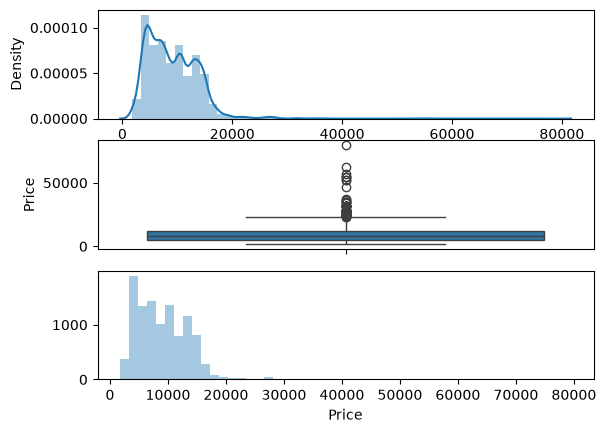

In [355]:
plot(df,'Price')

        If Features Are Skewed We Use the below Technique which is IQR
        Data which are greater than IQR +1.5 IQR and data which are below than IQR - 1.5 IQR are my outliers
        where ,  IQR = 75th%ile data - 25th%ile data
         
         & IQR +- 1.5 IQR  will be changed depending upon the domain ie it could be sometimes IQR +- 3IQR 

In [356]:
"For example, suppose I'm working with airline ticket prices and most of the prices are between ₹3,000 and ₹7,000, but I have one ticket priced at ₹25,000. I can use the IQR method to check whether this is an outlier. Suppose Q1 is ₹4,000 and Q3 is ₹6,500. So the IQR is ₹2,500. Using the 1.5×IQR rule, the upper boundary becomes ₹10,250. Since ₹25,000 is above this boundary, I would identify it as a potential outlier. However, I wouldn't immediately remove it. I would investigate whether ₹25,000 represents a genuine premium or business-class ticket or whether it is a data-quality issue."

"For example, suppose I'm working with airline ticket prices and most of the prices are between ₹3,000 and ₹7,000, but I have one ticket priced at ₹25,000. I can use the IQR method to check whether this is an outlier. Suppose Q1 is ₹4,000 and Q3 is ₹6,500. So the IQR is ₹2,500. Using the 1.5×IQR rule, the upper boundary becomes ₹10,250. Since ₹25,000 is above this boundary, I would identify it as a potential outlier. However, I wouldn't immediately remove it. I would investigate whether ₹25,000 represents a genuine premium or business-class ticket or whether it is a data-quality issue."

In [357]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1#formula

maximum = Q3 + 1.5*IQR # for Upper Boundaries
minimum = Q1 - 1.5*IQR # for Lower Boundaries

In [358]:
print(maximum)

23017.0


In [359]:
print(minimum)

-5367.0


In [360]:
print([price for price in df['Price'] if price> maximum or price<minimum])


[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 23583, 26890, 23533, 24115, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 23267, 62427, 54826, 31825, 25430, 26890, 36235, 23843, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 23170, 24528, 26890, 27992, 25735, 34608, 25703, 26890, 23528, 31825, 27282, 25735, 27992, 52285, 24017, 31945, 26890, 24318, 23677, 27992, 24210, 57209, 26890, 31825, 26480]


In [361]:
len([price for price in df['Price'] if price> maximum or price<minimum])

94

# How to deal with Outlier---->>>>

     np.where() is a NumPy function used to make a decision based on a condition.
     If this condition is true, give me this value; otherwise, give me that value.
     np.where(condition, value_if_true, value_if_false)

In [362]:
df['Price'] = np.where(df['Price']>=35000 , df['Price'].median() , df['Price'])

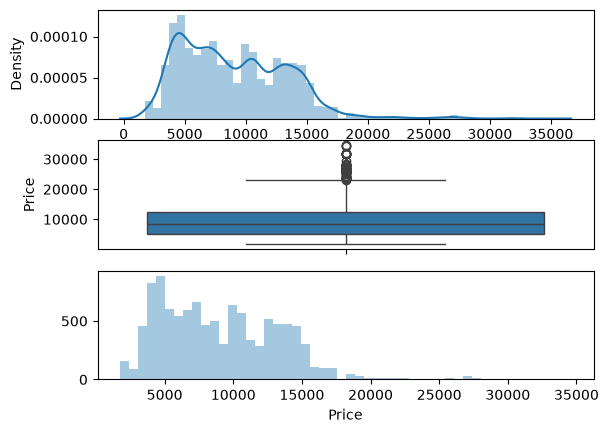

In [363]:
plot(df,'Price')

# 13..Lets perform Feature Selection..

In [364]:
'''
    : Feature Selection
    Finding out the best feature which will contribute and have good relation with target variable. 
    
    
    Q-> Why to apply Feature Selection?
    To select important features ie to get rid of curse of dimensionality ie..or to get rid of duplicate features
    
'''

'\n    : Feature Selection\n    Finding out the best feature which will contribute and have good relation with target variable. \n\n\n    Q-> Why to apply Feature Selection?\n    To select important features ie to get rid of curse of dimensionality ie..or to get rid of duplicate features\n\n'

In [368]:
X = df.drop(['Price'],axis = 1)

In [369]:
y = df['Price']

In [370]:
from sklearn.feature_selection import mutual_info_regression

In [372]:
info = mutual_info_regression(X,y)

In [373]:
'''
Estimate mutual information for a continuous target variable.

Mutual information between two random variables is a non-negative
value, which measures the dependency between the variables. 
If It is equal to zero it means two random variables are independent, and higher
values mean higher dependency.

'''

'\nEstimate mutual information for a continuous target variable.\n\nMutual information between two random variables is a non-negative\nvalue, which measures the dependency between the variables. \nIf It is equal to zero it means two random variables are independent, and higher\nvalues mean higher dependency.\n\n'

In [374]:
info

array([1.31610825, 1.06496641, 0.79203543, 0.36771308, 0.6232431 ,
       0.92413235, 0.76398168, 1.14149881, 0.8982328 , 0.95400123,
       0.67788899, 0.38707058, 0.4594068 , 0.5352224 , 0.12689359,
       0.20408575])

In [375]:
info_df = pd.DataFrame(info,index=X.columns)

In [376]:
info_df.columns = ['Importance']

In [377]:
info_df

,Importance
Airline,1.316108
Destination,1.064966
Total_Stops,0.792035
Journey_DAY,0.367713
Journey_MONTH,0.623243
Dep_Time_hrs,0.924132
Dep_Time_mins,0.763982
Arrival_Time_hrs,1.141499
Arrival_Time_mins,0.898233
Duration_hrs,0.954001


In [378]:
info_df.sort_values(by='Importance',ascending=False)

,Importance
Airline,1.316108
Arrival_Time_hrs,1.141499
Destination,1.064966
Duration_hrs,0.954001
Dep_Time_hrs,0.924132
Arrival_Time_mins,0.898233
Total_Stops,0.792035
Dep_Time_mins,0.763982
Duration_mins,0.677889
Journey_MONTH,0.623243


# 14..Lets Build Machine Learning Model--->>>

**split dataset into training and testing**

In [379]:
from sklearn.model_selection import train_test_split

In [380]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

#### what we often do in modelling:

    a..Initially ,lets build basic random model.
    b..then later-on , we will try to improve this model using some parameters..
    c..Then we will try to improve it..
    d..Then we will hyper-tune my model to get optimal value of parameters in order to achieve optimal value of params..

In [384]:
from sklearn.ensemble import RandomForestRegressor

In [385]:
rfr = RandomForestRegressor()

In [386]:
rfr.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb